In [1]:
# Librairies
import pickle
import numpy as np
import plotly.graph_objects as go
import healpy as hp
import matplotlib.pyplot as plt
import pandas as pd
import os

# Modules
import netcdf_read_write as nrw
import training_data_generation as tdg

# 1. Chargement des données 

In [2]:
with open("results/all_tree.pkl", "rb") as f:
    all_tree = pickle.load(f)

In [3]:
main_dir = "../Data/Data_run5"
sys_params = tdg.define_system_params(main_dir)
dataset_params = nrw.read_general_netcdf(main_dir + "/" + sys_params["dataset_params_filename"])

In [4]:
print(all_tree[0][0].keys())
print(all_tree[0][0]['dataset'].keys())
print(all_tree[0][0]['p_in_z1z2_beam_all'].keys())
print(all_tree[0][0]['ifriit_inputs'][0].keys())


dict_keys(['dataset', 'p_in_z1z2_beam_all', 'ifriit_inputs'])
dict_keys(['nside', 'avg_flux', 'real_modes', 'imag_modes', 'rms', 'power_deposited'])
dict_keys(['intensity', 'theta', 'phi'])
dict_keys(['PHI_DEG', 'P0_TW', 'FOC_UM', 'THETA_DEG'])


In [5]:
num_tree_max = len(all_tree)
num_pert_max = len(all_tree[0])
print("num_tree_max = " ,len(all_tree)-1)
print("num_pert_max = " ,len(all_tree[0])-1)

num_tree = 0
num_pert = 0

num_tree_max =  0
num_pert_max =  0


# 2. Visualisation 

In [6]:
beam_data = all_tree[num_tree][num_pert]['p_in_z1z2_beam_all']
beam_ifriit = all_tree[num_tree][num_pert]['ifriit_inputs']
dataset = all_tree[num_tree][num_pert]['dataset']
intensity = np.array(beam_data['intensity'])

R_int = 2307.0
R_p0 = 2307.0*2

#  Données de la sphère d'INTENSITÉ 
t_rad = np.array(beam_data['theta'])
p_rad = np.array(beam_data['phi'])
X_int = R_int * np.sin(t_rad) * np.cos(p_rad)
Y_int = R_int * np.sin(t_rad) * np.sin(p_rad)
Z_int = R_int * np.cos(t_rad)

# Données de PUISSANCE P0_TW 

ifriit_list = all_tree[num_tree][num_pert]['ifriit_inputs']
p0_vals = np.array([b['P0_TW'] for b in ifriit_list])
t_ifriit_rad = np.radians([b['THETA_DEG'] for b in ifriit_list])
p_ifriit_rad = np.radians([b['PHI_DEG'] for b in ifriit_list])

X_p0 = R_p0 * np.sin(t_ifriit_rad) * np.cos(p_ifriit_rad)
Y_p0 = R_p0 * np.sin(t_ifriit_rad) * np.sin(p_ifriit_rad)
Z_p0 = R_p0 * np.cos(t_ifriit_rad)

fig = go.Figure()

# sphère d'intensité 
fig.add_trace(go.Scatter3d(
    x=X_int, y=Y_int, z=Z_int,
    mode='markers',
    marker=dict(
        size=3,
        color=intensity,
        colorscale='Viridis',
        opacity=1.0,  
        showscale=True,
        colorbar=dict(title="Intensité", x=-0.1)
    ),
    name="Sphère d'Intensité",
    hoverinfo='skip'
))

# nuage de points P0_TW 
fig.add_trace(go.Scatter3d(
    x=X_p0, y=Y_p0, z=Z_p0,
    mode='markers',
    marker=dict(
        size=8,
        color=p0_vals,
        colorscale='YlOrRd',
        opacity=1.0,
        showscale=True,
        colorbar=dict(title="P0 (TW)", x=1.1),
        line=dict(color='black', width=2)
    ),
    name="Points P0 (Capsule)",
    text=[f"Faisceau P0: {p:.2f} TW" for p in p0_vals],
    hoverinfo='text+x+y+z'
))


fig.add_trace(go.Scatter3d(x=[0], y=[0], z=[0]))

fig.update_layout(
    title="Visualisation : Points P0_TW encapsulant la sphère d'Intensité",
    showlegend=False, 
    scene=dict(
        xaxis=dict(title='X', range=[-R_p0*1.1, R_p0*1.1]), # On utilise le rayon max avec 10% de marge
        yaxis=dict(title='Y', range=[-R_p0*1.1, R_p0*1.1]),
        zaxis=dict(title='Z', range=[-R_p0*1.1, R_p0*1.1]),
        aspectmode='cube'
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=50)
)
fig.show()


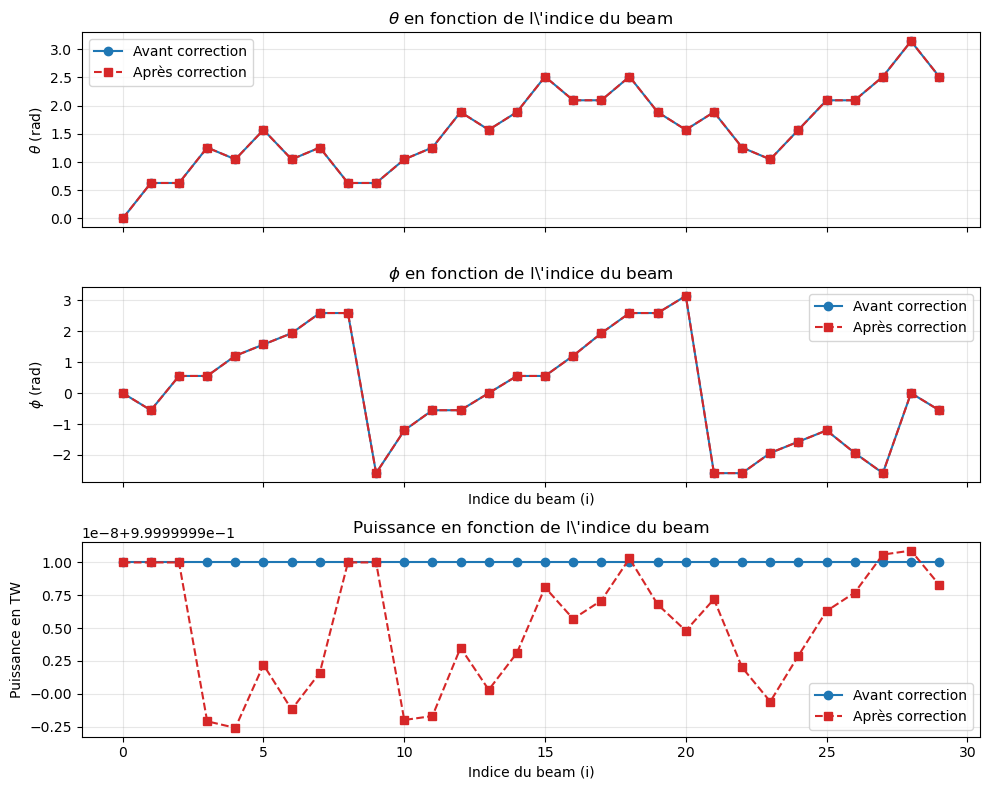

In [7]:
def cartesien_vers_spherique(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(np.clip(z / r, -1.0, 1.0))
    phi = np.arctan2(y, x)

    return r, theta, phi

# Config avant compensation
config_initial = {}
with open("results/config_initial.pkl", "rb") as file:
    config_initial = pickle.load(file)
num_pert = 0
theta_avant = config_initial[num_pert]['P_theta']
phi_avant = config_initial[num_pert]['P_phi']
P0 = config_initial[num_pert]['P0']


# --- Données "après correction"  ---
theta_apres_rad = []
phi_apres_rad = []
for b in range(len(all_tree[num_tree][num_pert]['ifriit_inputs'])):
    X = cartesien_vers_spherique(*all_tree[num_tree][num_pert]['ifriit_inputs'][b]['FOC_UM'])
    theta_apres_rad.append(X[1])
    phi_apres_rad.append(X[2])
theta_apres = np.array(theta_apres_rad)
phi_apres   = np.array(phi_apres_rad)


n_avant, n_apres = len(theta_avant), len(theta_apres)
if n_avant != n_apres:
    print(f" Nombre de beams différent (avant={n_avant}, après={n_apres}). "
          "La comparaison indice par indice peut être faussée si l'ordre des beams diffère.")

i_avant = np.arange(n_avant)
i_apres = np.arange(n_apres)

# --- Tracé ---
fig, (ax_theta,ax_phi,ax_puissance) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Graphe 0 : theta
ax_theta.plot(i_avant, theta_avant, 'o-', color='tab:blue', label='Avant correction')
ax_theta.plot(i_apres, theta_apres, 's--', color='tab:red', label='Après correction')
ax_theta.set_ylabel(r'$\theta$ (rad)')
ax_theta.set_title(r'$\theta$ en fonction de l\'indice du beam')
ax_theta.grid(True, alpha=0.3)
ax_theta.legend()

# Graphe 1 : phi
ax_phi.plot(i_avant, phi_avant, 'o-', color='tab:blue', label='Avant correction')
ax_phi.plot(i_apres, phi_apres, 's--', color='tab:red', label='Après correction')
ax_phi.set_xlabel('Indice du beam (i)')
ax_phi.set_ylabel(r'$\phi$ (rad)')
ax_phi.set_title(r'$\phi$ en fonction de l\'indice du beam')
ax_phi.grid(True, alpha=0.3)
ax_phi.legend()

# Graphe 2 : puissance
ax_puissance.plot(i_avant, P0, 'o-', color='tab:blue', label='Avant correction')
ax_puissance.plot(i_apres, p0_vals, 's--', color='tab:red', label='Après correction')
ax_puissance.set_xlabel('Indice du beam (i)')
ax_puissance.set_ylabel(r'Puissance en TW')
ax_puissance.set_title(r'Puissance en fonction de l\'indice du beam')
ax_puissance.grid(True, alpha=0.3)
ax_puissance.legend()

plt.tight_layout()
plt.show()

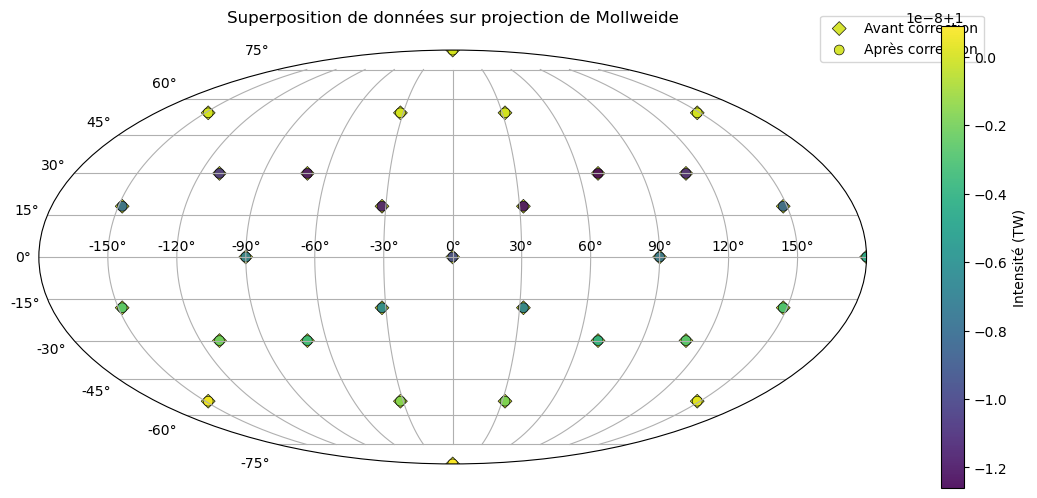

In [19]:
cmap_commun = 'viridis'
vmin = np.minimum(P0.min(), p0_vals.min())
vmax = np.maximum(P0.max(), p0_vals.max())

theta_avant_ = np.pi/2 - theta_avant 
theta_apres_ = np.pi/2 - theta_apres

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='mollweide')

scatter1 = ax.scatter(
    phi_avant, theta_avant_,
    c=P0, cmap=cmap_commun, vmin=vmin, vmax=vmax,
    marker='D', s=50,
    edgecolors='black', linewidths=0.5,
    alpha=0.9,
    label='Avant correction'
)
scatter2 = ax.scatter(
    phi_apres, theta_apres_,
    c=p0_vals, cmap=cmap_commun, vmin=vmin, vmax=vmax,
    marker='o', s=50,
    edgecolors='black', linewidths=0.5,
    alpha=0.9,
    label='Après correction'
)

cbar = fig.colorbar(scatter1, ax=ax, orientation='vertical', pad=0.08, fraction=0.03)
cbar.set_label('Intensité (TW)')
ax.grid(True)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.1))
plt.title("Superposition de données sur projection de Mollweide", pad=20)
plt.show()

# 3. Analyse de $\sigma_{RMS}$

## 3.1 Visualisation des $\sigma_{RMS}$ en fonction de l'arbre et de la perturbation

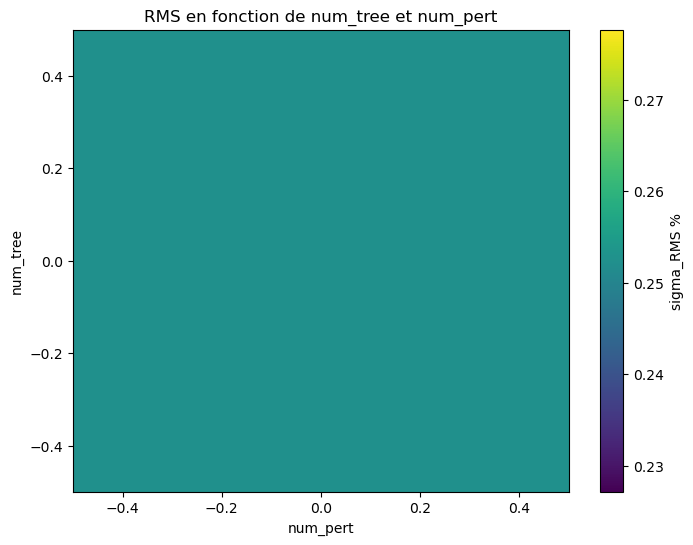

In [9]:
n_tree = len(all_tree)
n_pert = len(all_tree[0])

rms_matrix = np.zeros((n_tree, n_pert))

for num_tree in range(n_tree):
    for num_pert in range(n_pert):
        rms_matrix[num_tree, num_pert] = all_tree[num_tree][num_pert]['dataset']['rms']

plt.figure(figsize=(8, 6))

plt.imshow(100*rms_matrix,
           origin='lower',
           aspect='auto',
           cmap='viridis')

plt.colorbar(label='sigma_RMS %')
plt.xlabel('num_pert')
plt.ylabel('num_tree')
plt.title('RMS en fonction de num_tree et num_pert')

plt.show()

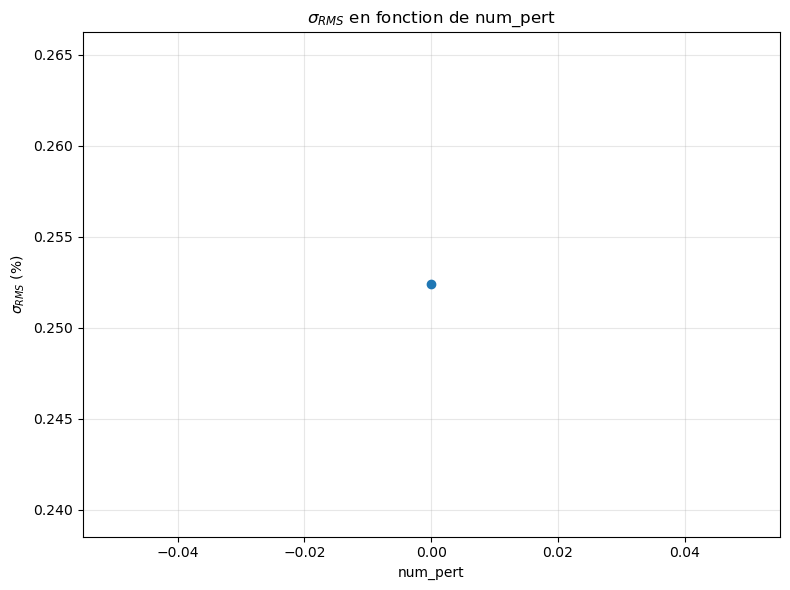

In [10]:
n_tree = len(all_tree)
n_pert = len(all_tree[0])

rms_matrix = np.zeros((n_tree, n_pert))

for num_tree in range(n_tree):
    for num_pert in range(n_pert):
        rms_matrix[num_tree, num_pert] = all_tree[num_tree][num_pert]['dataset']['rms']

plt.figure(figsize=(8, 6))

x = np.arange(n_pert)

for num_tree in range(n_tree):
    plt.plot(
        x,
        100 * rms_matrix[num_tree, :],
        marker='o',
        label=f'tree {num_tree}'
    )

plt.xlabel('num_pert')
plt.ylabel(r'$\sigma_{RMS}$ (%)')
plt.title(r'$\sigma_{RMS}$ en fonction de num_pert')
plt.grid(True, alpha=0.3)
# plt.legend()
plt.tight_layout()

plt.show()

In [11]:
ind_min_pert = 0
ind_min_tree = 0
min = rms_matrix[0][0]

for i in range(n_tree):
    for j in range(n_pert):
        if rms_matrix[i][j] < min:
            ind_min_tree = i
            ind_min_pert = j
            min = rms_matrix[i][j]

print(f"Le minmium est atteint à la perturbation {ind_min_pert} de l'arbre {ind_min_tree} et vaut {min}.")

Le minmium est atteint à la perturbation 0 de l'arbre 0 et vaut 0.002523879398045027.


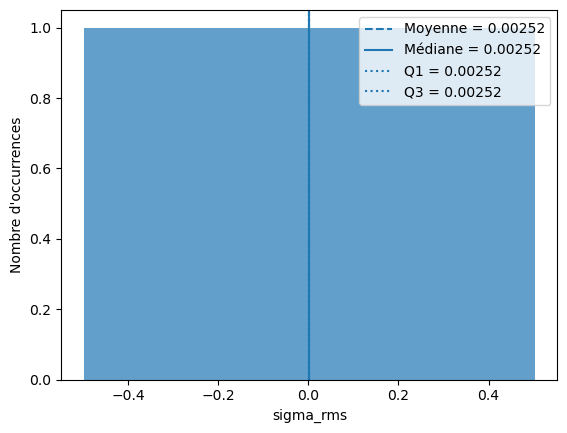

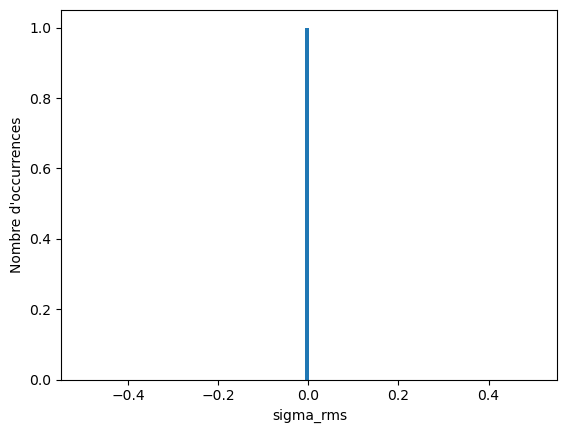

In [12]:
sigma_rms = []
num_tree = 0
for num_tree in range(n_tree):
    sigma_rms.append(all_tree[num_tree][num_pert]['dataset']['rms'])

# Statistiques
mean = np.mean(sigma_rms)
median = np.median(sigma_rms)
q1 = np.percentile(sigma_rms, 25)
q3 = np.percentile(sigma_rms, 75)

# Histogramme
plt.hist(sigma_rms, bins='auto', alpha=0.7) 

# Lignes verticales
plt.axvline(mean, linestyle='--', label=f'Moyenne = {mean:.5f}')
plt.axvline(median, linestyle='-', label=f'Médiane = {median:.5f}')
plt.axvline(q1, linestyle=':', label=f'Q1 = {q1:.5f}')
plt.axvline(q3, linestyle=':', label=f'Q3 = {q3:.5f}')

plt.xlabel('sigma_rms')
plt.ylabel('Nombre d\'occurrences')
plt.legend()
plt.show()

# Histogramme plus précis
plt.figure()
plt.hist(sigma_rms, bins=100) 
plt.xlabel('sigma_rms')
plt.ylabel('Nombre d\'occurrences')
plt.show()

## 3.2 Distribution de la profondeur de l'arbre par rapport à un seuil sur $\sigma_{RMS}$

In [13]:
depth_values = []

seuil = 0.01
# Parcours de la structure imbriquée all_tree
for i in range(num_tree_max):
    for j in range(num_pert_max):
        dataset = all_tree[i][j]['dataset']
        if dataset['rms']> seuil or j==num_pert_max-1:
            depth_values.append(j)
            break

depths, occurrences = np.unique(depth_values, return_counts=True)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=depths,
    y=occurrences,
    marker=dict(
        color=occurrences,          # Colore la barre selon le nombre d'occurrences
        colorscale='Plasma',        # Palette de couleur distincte
        line=dict(color='black', width=1)
    ),
    text=occurrences,               # Affiche le nombre directement sur/au-dessus de la barre
    textposition='auto',
    name='Occurrences'
))

# Configuration du layout
fig.update_layout(
    title=f"Distribution des profondeurs (Depth) pour RMS > {seuil}",
    xaxis=dict(
        title="Depth (Profondeur / Indice de perturbation)",
        tickmode='linear',          # Force l'affichage de chaque entier sur l'axe X
        dtick=1
    ),
    yaxis=dict(
        title="Nombre d'occurrences (Fréquence)"
    ),
    width=800,
    height=500,
    template="plotly_white"
)

fig.show()

## 3.3 Lien avec la MTTF

97.39583333333334


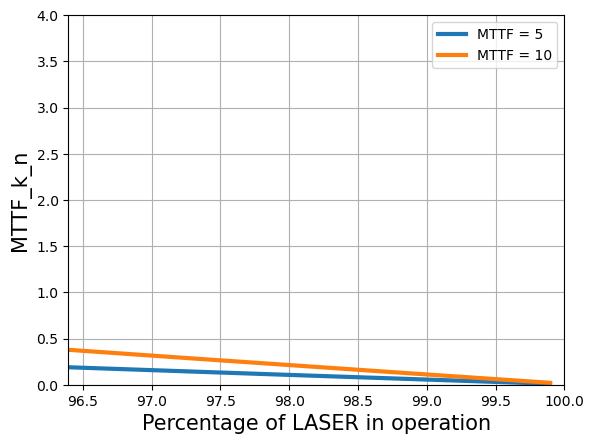

In [14]:
n = 960
k = 25
print((n-k)/n*100)
i = np.arange(1, n+1)
harmonic = np.cumsum(1 / i)
def sommeInverse_fast(n, k):
    return harmonic[n-1] - (harmonic[k-2] if k > 1 else 0)

k_values = np.arange(1, n)
sums = np.array([sommeInverse_fast(n, k) for k in k_values])

MTTF_list = np.array([ 5,10  ])
k_values_pct = k_values / n * 100
for MTTF in MTTF_list:
    plt.plot(k_values_pct, MTTF * sums, label=f"MTTF = {MTTF}", lw = 3)

plt.xlabel("Percentage of LASER in operation",fontsize = 15)
plt.ylabel("MTTF_k_n",fontsize = 15)
plt.legend()
plt.grid()
plt.xlim([(n-k)/n*100 - 1 , 100])
plt.ylim([0,4])
plt.show()

# 4. Analyse des modes 

## 4.1 Intensité des modes l 

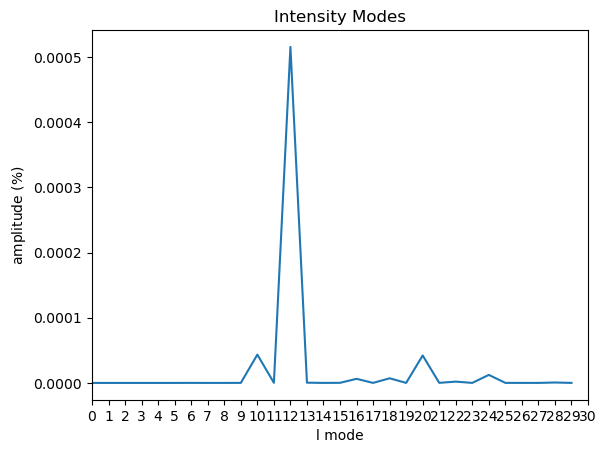

In [15]:
def plot_power_spectrum(dataset, dataset_params,i):
    def alms2power_spectrum(alms, LMAX):
        #Cette fonction calcule les $\sigma_{l}^2 / \bar{I}$
        the_modes = np.zeros(LMAX)
        the_modes_full = np.zeros((LMAX,LMAX+1))
        for l in range(LMAX):
            for m in range(l+1):
                the_modes_full[l,m] = np.real(alms[hp.sphtfunc.Alm.getidx(LMAX, l, m)]*
                    np.conjugate(alms[hp.sphtfunc.Alm.getidx(LMAX, l, m)]))
                if (m>0):
                    the_modes[l] = the_modes[l] + 2.*the_modes_full[l,m]
                else:          
                    the_modes[l] = the_modes[l] + the_modes_full[l,m]

        the_modes = the_modes / (4.*np.pi)
        return the_modes
    
    
    real_modes = dataset["real_modes"]
    imag_modes = dataset["imag_modes"]
    complex_modes = real_modes + 1j * imag_modes
    

    power_spectrum = alms2power_spectrum(complex_modes, LMAX)
    # print("sigma_RMS % = ",100* np.sqrt(np.sum(power_spectrum)))
    

    plt.plot(np.arange(LMAX), power_spectrum * 100.0,label=f"pert = {i}")




LMAX = dataset_params["LMAX"]

fig = plt.figure()
ax = plt.axes()
ax.set_xticks(range(0, LMAX+1, 1))
plt.xlim([0, LMAX])
plt.title("Intensity Modes")
plt.xlabel("l mode")
plt.ylabel(r"amplitude ($\%$)")
for i in range(len(all_tree)):
    dataset = all_tree[i][0]['dataset']
    plot_power_spectrum(dataset, dataset_params,i)
# plt.legend()


# print('le vrai sigma RMS en %: ', dataset['rms']*100)

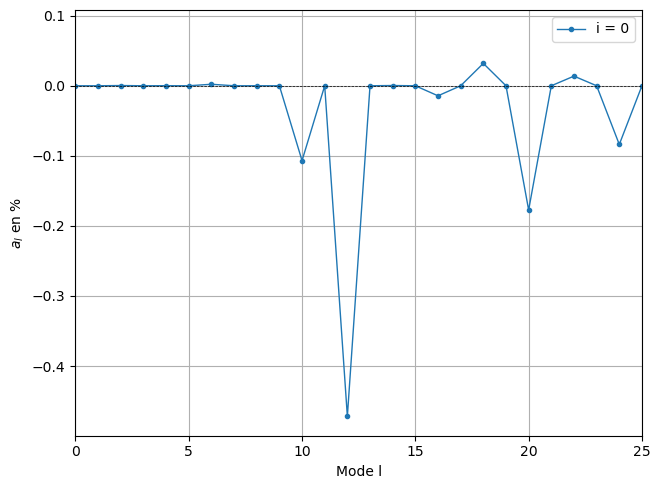

In [16]:
def plot_al(alms, lmax,leg):
    ells = np.arange(lmax + 1)
    
    # Récupère les a_{l,0} qui sont nécessairements réels pour un champ réel
    al0 = np.array([alms[hp.Alm.getidx(lmax, l, 0)].real for l in ells])
    
    # Applique le facteur
    al = al0* np.sqrt((2 * ells + 1) / (4 * np.pi))
    al = al*100
    # Tracé
    # plt.figure(figsize=(8, 4))
    plt.plot(ells, al, marker='o', markersize=3, linewidth=1,label=leg)
    plt.axhline(0, color='k', linewidth=0.5, linestyle='--')
    plt.tight_layout()
    plt.grid(axis = 'both')
    plt.xlabel("Mode l")
    plt.ylabel("$a_l$ en %")
    plt.xlim([0,25.0])
    # plt.ylim([-0.6,0.1])
    
    
    return al

num_tree = 0
i=0
dataset = all_tree[num_tree][0+i*5]['dataset']
real_modes = dataset["real_modes"]
imag_modes = dataset["imag_modes"]
alms = real_modes + 1j * imag_modes
lmax = dataset_params["LMAX"]
plot_al(alms, lmax,f"i = {i}")# en %

plt.legend()
plt.show()